# 02 · Baselines (from scratch)
Report section: *Baseline methods* + part of *Results*. Runs LDA, QDA, kNN on the leakage-safe split, plus the naive reference baselines (tasks D1, D3).

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.baselines import GaussianClassifier, KNNClassifier, MajorityClassifier
from src.metrics import accuracy, precision_recall_f1, log_loss, confusion_matrix
from src.plotting import plot_confusion_matrix, save_fig

## 1. Load the leakage-safe split
`build_dataset` composes load -> features -> chronological split -> symmetrize -> train-only impute -> train-only scale. The model trains/evaluates on the symmetrized split; the original-corner test is kept for the naive/market references.

In [2]:
ds = build_dataset(test_frac=0.2, seed=0)
Xtr, ytr = ds.X_train.values, ds.y_train.values
Xte, yte = ds.X_test.values, ds.y_test.values
print(f'train {len(Xtr)}, test {len(Xte)}, features {Xtr.shape[1]}')

train 5529, test 1382, features 112


## 2. Baseline panel (D1)
LDA, QDA (regularized - unregularized QDA is ill-conditioned in 112 dims, log-loss ~11), and kNN. Metrics on the symmetrized 6-class test.

In [3]:
models = {
    'LDA': GaussianClassifier('lda'),
    'QDA': GaussianClassifier('qda', reg=1.0),   # reg=1.0: full per-class cov overfits in 112-d
    'kNN (k=15)': KNNClassifier(k=15),
}
fitted, preds, probas, rows = {}, {}, {}, []
for name, m in models.items():
    m.fit(Xtr, ytr); fitted[name] = m
    preds[name] = m.predict(Xte); probas[name] = m.predict_proba(Xte)
    rows.append({'model': name,
                 'accuracy': accuracy(yte, preds[name]),
                 'macro_F1': precision_recall_f1(yte, preds[name])['macro_f1'],
                 'log_loss': log_loss(yte, probas[name], classes=fitted[name].classes_)})
panel = pd.DataFrame(rows).set_index('model').round(3); panel

,accuracy,macro_F1,log_loss
model,,,
LDA,0.355,0.328,1.599
QDA,0.250,0.234,3.149
kNN (k=15),0.276,0.233,3.477


## 3. Collapse to winner / method
6-class accuracy is hard to read against 2-class references, so we collapse each model's predictions to the winner (Red/Blue) and to the method (KO/SUB/DEC) and score those.

In [4]:
winner = lambda a: np.array([s.split('-')[0] for s in a])
method = lambda a: np.array([s.split('-')[1] for s in a])
rows = [{'model': n,
         'winner_acc': accuracy(winner(yte), winner(preds[n])),
         'method_acc': accuracy(method(yte), method(preds[n]))} for n in fitted]
pd.DataFrame(rows).set_index('model').round(3)

,winner_acc,method_acc
model,,
LDA,0.630,0.524
QDA,0.572,0.403
kNN (k=15),0.536,0.497


## 4. Naive reference baselines (D3)
Majority class (symmetrized test) and always-red (winner-level, on the ORIGINAL corners - symmetrization would flatten it to ~50%).

In [5]:
maj = MajorityClassifier().fit(Xtr, ytr)
w_orig = ds.y_test_orig.str.split('-').str[0]
print(f'majority ({maj.majority_}):       6-class acc = {maj.score(Xte, yte):.3f}')
print(f'always-red (winner-level, orig): acc = {(w_orig == "Red").mean():.3f}')
print(f'coin flip (winner):              0.500')

majority (Red-DEC):       6-class acc = 0.255
always-red (winner-level, orig): acc = 0.562
coin flip (winner):              0.500


## 5. Confusion matrix (best baseline)

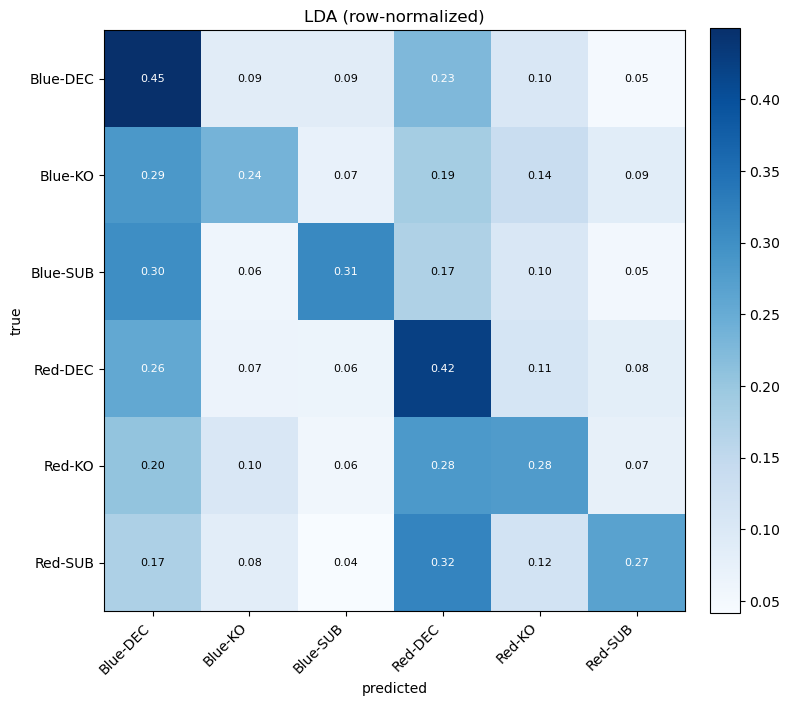

best baseline: LDA


In [6]:
best = max(fitted, key=lambda n: accuracy(yte, preds[n]))
M, classes = confusion_matrix(yte, preds[best], classes=fitted[best].classes_)
plot_confusion_matrix(M, classes, normalize=True)
plt.title(f'{best} (row-normalized)'); save_fig('confusion_matrix_baseline'); plt.show()
print('best baseline:', best)